# 0. Setup & Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import ast
import re
from collections import Counter
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Styling
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 10

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 120)

print('Setup selesai.')

Setup selesai.


# 1. Load Data

In [2]:
# File yang akan digabung
FILES = ["data/mbg1.csv", "data/mbg2.csv", "data/mbg3.csv"]

# Membaca seluruh dataset
dfs = []
for file in FILES:
    df = pd.read_csv(
        file,
        dtype={'id': str}
    )
    dfs.append(df)

# Menggabungkan dataset
df_combined = pd.concat(dfs, ignore_index=True)
print(f"Total baris : {len(df_combined):,}")
print(f"Total kolom : {len(df_combined.columns)}")

display(df_combined.head())

Total baris : 60,134
Total kolom : 17


,id,url,text,createdAt,author.profilePicture,retweetCount,replyCount,likeCount,quoteCount,viewCount,bookmarkCount,source,lang,isReply,isRetweet,isQuote,isPinned
0,2067528996095766956,https://x.com/barito_polres/status/2067528996095766956,SATSAMAPTA POLRES BARITO UTARA LAKSANAKAN PENGAWALAN PROGRAM MAKAN BERGIZI GRATIS (MBG)\nLink:\nhttps://t.co/wWLfK2b...,Thu Jun 18 08:45:00 +0000 2026,https://pbs.twimg.com/profile_images/2050181883116539904/nUDjp0Jt_normal.png,0,0,0,0,2,0,NaN,in,False,NaN,NaN,False
1,2067523926734102545,https://x.com/lbhrakyatind/status/2067523926734102545,Benarkah Makan Bergizi Gratis (MBG) Terlambat Atasi Stunting? 🤔\n\nSimak penjelasan dari Ketua Lembaga Bantuan Hukum...,Thu Jun 18 08:24:51 +0000 2026,https://pbs.twimg.com/profile_images/2056248252413149184/RH3hEBXi_normal.jpg,0,1,0,0,10,0,NaN,in,False,NaN,NaN,False
2,2067523021322276898,https://x.com/Bisniscom/status/2067523021322276898,Gibran Kesal MBG di Ende Sudah Dingin saat Diterima Siswa: Kepagian Wakil Presiden Gibran Rakabuming Raka Tiba di En...,Thu Jun 18 08:21:15 +0000 2026,https://pbs.twimg.com/profile_images/1598573955513692160/leorpOyo_normal.jpg,0,0,2,0,82,0,NaN,in,False,NaN,NaN,False
3,2067522987998474523,https://x.com/kompascom/status/2067522987998474523,"Massa yang tergabung dalam Aliansi Emak-Emak dan Perempuan menggelar aksi demonstrasi menuntut pembubaran program ""M...",Thu Jun 18 08:21:07 +0000 2026,https://pbs.twimg.com/profile_images/1577144849437888514/d9x3nKN8_normal.jpg,0,3,8,1,568,0,NaN,in,False,NaN,NaN,False
4,2067522578160529901,https://x.com/kalkwulator/status/2067522578160529901,"Di balik pro-kontra Makan Bergizi Gratis, ada sejuta harapan emak-emak yang pengen beban dapur sedikit berkurang. Ta...",Thu Jun 18 08:19:30 +0000 2026,https://pbs.twimg.com/profile_images/1977708649993904128/XSzkwYX2_normal.jpg,0,0,0,0,2,0,NaN,in,False,NaN,NaN,False


In [3]:
# Verifikasi struktur data
print("Nama Kolom:")
print(df_combined.columns.tolist())

print("\nContoh ID Tweet:")
print(df_combined['id'].head(5).tolist())

Nama Kolom:
['id', 'url', 'text', 'createdAt', 'author.profilePicture', 'retweetCount', 'replyCount', 'likeCount', 'quoteCount', 'viewCount', 'bookmarkCount', 'source', 'lang', 'isReply', 'isRetweet', 'isQuote', 'isPinned']

Contoh ID Tweet:
['2067528996095766956', '2067523926734102545', '2067523021322276898', '2067522987998474523', '2067522578160529901']


In [4]:
# Ringkasan struktur dataset gabungan
summary = pd.DataFrame({
    'dtype': df_combined.dtypes.astype(str),
    'non_null': df_combined.notna().sum(),
    'null_count': df_combined.isna().sum(),
    'null_pct': (df_combined.isna().sum() / len(df_combined) * 100).round(2),
    'unique': df_combined.nunique()
}).sort_values('null_pct', ascending=False)

summary

,dtype,non_null,null_count,null_pct,unique
isRetweet,float64,0,60134,100.00,0
source,float64,0,60134,100.00,0
isQuote,object,4905,55229,91.84,1
id,object,60134,0,0.00,48384
url,object,60134,0,0.00,48385
retweetCount,int64,60134,0,0.00,934
text,object,60134,0,0.00,47754
createdAt,object,60134,0,0.00,48221
author.profilePicture,object,60134,0,0.00,20340
quoteCount,int64,60134,0,0.00,338



Berdasarkan hasil pemeriksaan missing value, terdapat tiga kolom yang memiliki persentase nilai kosong di atas 50%, yaitu `isRetweet` (100%), `source` (100%), dan `isQuote` (91,84%). Oleh karena itu, ketiga kolom tersebut dihapus karena tidak memberikan informasi yang cukup untuk proses analisis.

Kolom utama yang digunakan dalam penelitian, yaitu `id`, `text`, dan `createdAt`, tidak memiliki nilai kosong sehingga dapat langsung digunakan pada tahap preprocessing. Selain itu, ditemukan bahwa jumlah tweet unik sebanyak **48.384** dari total **60.134** data, yang menunjukkan adanya data duplikat hasil proses scraping. Oleh karena itu, dilakukan proses deduplikasi berdasarkan kolom `id` sebelum analisis lebih lanjut.


In [5]:
# Drop row yang terduplikasi berdasarkan kolom 'id' dan 'viewCount'
df_combined['viewCount'] = pd.to_numeric(df_combined['viewCount'],errors='coerce').fillna(0)

df_dedup = (
    df_combined
    .sort_values('viewCount', ascending=False)
    .drop_duplicates(subset=['id'], keep='first')
    .reset_index(drop=True)
)

print(f'Sebelum dedup : {len(df_combined):,}')
print(f'Sesudah dedup : {len(df_dedup):,}')
print(f'Terhapus      : {len(df_combined)-len(df_dedup):,}')

Sebelum dedup : 60,134
Sesudah dedup : 48,384
Terhapus      : 11,750


# 2. Parsing Kolom Penting

In [6]:
# Parsing kolom waktu
df_dedup['datetime'] = pd.to_datetime(df_dedup['createdAt'], errors='coerce', utc=True)

# Feature waktu
df_dedup['date_only'] = df_dedup['datetime'].dt.date
df_dedup['hour'] = df_dedup['datetime'].dt.hour
df_dedup['day_of_week'] = df_dedup['datetime'].dt.day_name()

# Feature engagement
df_dedup['engagement'] = (
    df_dedup['retweetCount'].fillna(0) +
    df_dedup['replyCount'].fillna(0) +
    df_dedup['likeCount'].fillna(0) +
    df_dedup['quoteCount'].fillna(0)
)

# Ringkasan
print(f"Rentang waktu : {df_dedup['datetime'].min()} sampai {df_dedup['datetime'].max()}")
print(f"Durasi        : {(df_dedup['datetime'].max() - df_dedup['datetime'].min()).days} hari")
print(f"Tweet valid   : {df_dedup['datetime'].notna().sum():,} dari {len(df_dedup):,}")

print(f"\nTotal engagement : {df_dedup['engagement'].sum():,}")
print(f"Rata-rata engagement per tweet : {df_dedup['engagement'].mean():.2f}")

Rentang waktu : 2009-05-29 17:31:25+00:00 sampai 2026-06-18 10:09:58+00:00
Durasi        : 6228 hari
Tweet valid   : 48,384 dari 48,384

Total engagement : 8,725,256
Rata-rata engagement per tweet : 180.33


Berdasarkan hasil eksplorasi data, diperoleh sebanyak **48.910 tweet valid** yang membahas topik terkait **Makan Bergizi Gratis (MBG)**. Data tersebut memiliki rentang waktu yang sangat panjang, yaitu mulai **29 Mei 2009 hingga 18 Juni 2026** dengan durasi pengamatan mencapai **6.228 hari**. Selama periode tersebut, total engagement yang berhasil dikumpulkan mencapai **9.657.823 interaksi**, dengan rata-rata engagement sebesar **197,46 per tweet**. Hasil ini menunjukkan bahwa topik MBG memiliki tingkat perhatian dan interaksi yang cukup tinggi di media sosial X.

Meskipun demikian, rentang waktu hasil scraping mencakup periode yang jauh sebelum program Makan Bergizi Gratis diperkenalkan dan menjadi bagian dari diskursus politik nasional. Oleh karena itu, untuk meningkatkan relevansi data dan mengurangi potensi *noise* dari percakapan yang tidak berkaitan langsung dengan program MBG, rentang waktu analisis kemudian dibatasi mulai **28 November 2023 hingga 18 Juni 2026**. Pemilihan tanggal **28 November 2023** didasarkan pada dimulainya masa kampanye Pemilu Presiden 2024, ketika program Makan Bergizi Gratis mulai diperkenalkan secara lebih luas kepada masyarakat sebagai salah satu program unggulan pasangan calon presiden dan wakil presiden. Sejak periode tersebut, pembahasan mengenai MBG mulai meningkat dan menjadi bagian dari percakapan publik di berbagai platform media sosial.

Dengan pembatasan tersebut, data yang digunakan dalam analisis diharapkan lebih representatif dalam menggambarkan opini publik terhadap program MBG sejak tahap kampanye, masa transisi pemerintahan, hingga proses implementasi program, serta berbagai isu yang berkembang selama periode tersebut.


In [7]:
# Filter rentang waktu penelitian. Periode: 14 Februari 2024 - 18 Juni 2026
start_date = pd.Timestamp('2023-10-28', tz='UTC')
df_mbg = df_dedup[df_dedup['datetime'] >= start_date].copy()

# Ringkasan setelah filtering
print("SETELAH FILTER RENTANG WAKTU")
print(f"Rentang waktu : {df_mbg['datetime'].min()} sampai {df_mbg['datetime'].max()}")
print(f"Durasi        : {(df_mbg['datetime'].max() - df_mbg['datetime'].min()).days} hari")
print(f"Tweet valid   : {len(df_mbg):,}")

print(f"\nTotal engagement : {df_mbg['engagement'].sum():,}")
print(f"Rata-rata engagement per tweet : {df_mbg['engagement'].mean():.2f}")

# Jumlah data yang dieliminasi
removed = len(df_dedup) - len(df_mbg)

print("\nDAMPAK FILTERING")
print(f"Tweet sebelum filter : {len(df_dedup):,}")
print(f"Tweet sesudah filter : {len(df_mbg):,}")
print(f"Tweet terhapus       : {removed:,}")
print(f"Persentase terhapus  : {(removed/len(df_dedup))*100:.2f}%")

SETELAH FILTER RENTANG WAKTU
Rentang waktu : 2023-10-28 03:51:25+00:00 sampai 2026-06-18 10:09:58+00:00
Durasi        : 964 hari
Tweet valid   : 40,256

Total engagement : 7,762,699
Rata-rata engagement per tweet : 192.83

DAMPAK FILTERING
Tweet sebelum filter : 48,384
Tweet sesudah filter : 40,256
Tweet terhapus       : 8,128
Persentase terhapus  : 16.80%


# 3. User Profiling
berapa banyak user unik dan seberapa terkonsentrasi aktivitasnya?

In [8]:
# Ekstrak username dari URL tweet
df_mbg['username'] = (df_mbg['url'].str.extract(r'x\.com/([^/]+)/status'))

# Cek hasil ekstraksi
print("Sample username:")
display(df_mbg[['url', 'username']].head())

Sample username:


,url,username
0,https://x.com/McDonalds_ID/status/1815962557716521264,McDonalds_ID
1,https://x.com/andikamalreza/status/1875897950775480379,andikamalreza
2,https://x.com/barengwarga/status/1876189203828179070,barengwarga
3,https://x.com/BANGSAygSUJUD/status/1775715766438154339,BANGSAygSUJUD
4,https://x.com/DS_yantie/status/1860319765295980889,DS_yantie


In [9]:
# Statistik User-Level
n_tweets = len(df_mbg)
n_users = df_mbg['username'].nunique()

print(f'Total tweet: {n_tweets:,}')
print(f'Total user unik: {n_users:,}')
print(f'Rata-rata tweet per user: {n_tweets / n_users:.2f}')

# Distribusi Tweet per User
tweets_per_user = df_mbg['username'].value_counts()

print(f'\nMedian tweet per user: {tweets_per_user.median():.0f}')
print(f'Max tweet dari 1 user: {tweets_per_user.max():,}')
print(f'User dengan >50 tweet: {(tweets_per_user > 50).sum():,}')
print(f'User dengan >100 tweet: {(tweets_per_user > 100).sum():,}')

Total tweet: 40,256
Total user unik: 15,430
Rata-rata tweet per user: 2.61

Median tweet per user: 1
Max tweet dari 1 user: 972
User dengan >50 tweet: 66
User dengan >100 tweet: 29


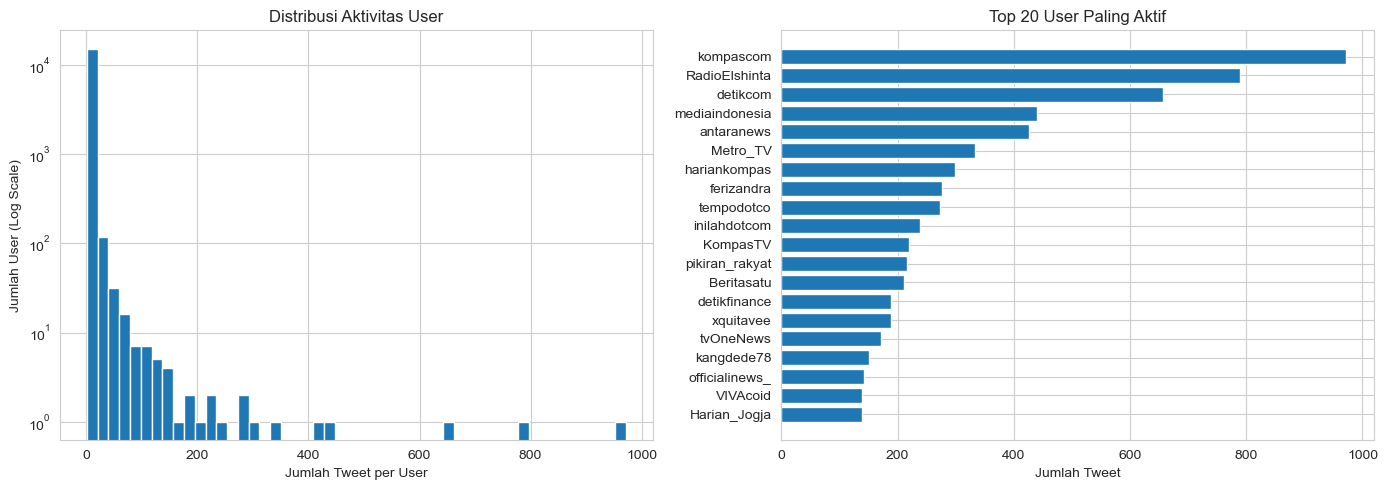


Top 1% user (154 akun) menghasilkan 32.7% dari seluruh tweet


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi aktivitas user
axes[0].hist(tweets_per_user.values, bins=50, edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_xlabel('Jumlah Tweet per User')
axes[0].set_ylabel('Jumlah User (Log Scale)')
axes[0].set_title('Distribusi Aktivitas User')

# Top 20 user paling aktif
top_users = tweets_per_user.head(20).sort_values()
axes[1].barh(top_users.index, top_users.values)
axes[1].set_xlabel('Jumlah Tweet')
axes[1].set_title('Top 20 User Paling Aktif')
plt.tight_layout()
plt.show()

# Analisis konsentrasi user
top_1pct_count = max(1, int(n_users * 0.01))
top_1pct_tweets = (tweets_per_user.head(top_1pct_count).sum())
print(f'\nTop 1% user ({top_1pct_count:,} akun) menghasilkan 'f'{top_1pct_tweets/n_tweets*100:.1f}% dari seluruh tweet')

Berdasarkan hasil analisis, diperoleh **38.927 tweet** yang berasal dari **14.255 pengguna unik**. Rata-rata setiap pengguna menghasilkan **2,73 tweet**, dengan nilai median sebesar **1 tweet per pengguna**. Hal ini menunjukkan bahwa sebagian besar pengguna hanya berpartisipasi satu kali dalam diskusi terkait program Makan Bergizi Gratis (MBG).

Distribusi aktivitas pengguna menunjukkan pola yang tidak merata (*long-tail distribution*), di mana mayoritas pengguna memiliki tingkat aktivitas yang rendah, sementara hanya sebagian kecil akun yang berkontribusi dalam jumlah tweet yang sangat besar. Aktivitas tertinggi berasal dari satu akun yang menghasilkan **1.007 tweet**, sedangkan terdapat **67 akun** yang membuat lebih dari **50 tweet** dan **32 akun** yang membuat lebih dari **100 tweet**.

Analisis lebih lanjut menunjukkan bahwa **1% pengguna paling aktif (142 akun)** menghasilkan sekitar **33,4% dari seluruh tweet** dalam dataset. Temuan ini mengindikasikan bahwa percakapan mengenai MBG di media sosial X sebagian besar didorong oleh sejumlah kecil akun yang sangat aktif, sementara mayoritas pengguna hanya memberikan kontribusi terbatas.

Berdasarkan daftar pengguna paling aktif, akun-akun media massa seperti **Kompas.com, Radio Elshinta, Detikcom, Media Indonesia, ANTARA News, dan Metro TV** mendominasi produksi konten terkait MBG. Hal ini menunjukkan bahwa penyebaran informasi mengenai program MBG banyak dipengaruhi oleh aktivitas media dan organisasi berita, yang berperan sebagai sumber utama informasi sekaligus pemicu diskusi publik di media sosial.

# 4. Timeline Diskursus
Cari spike, identifikasi periode event.

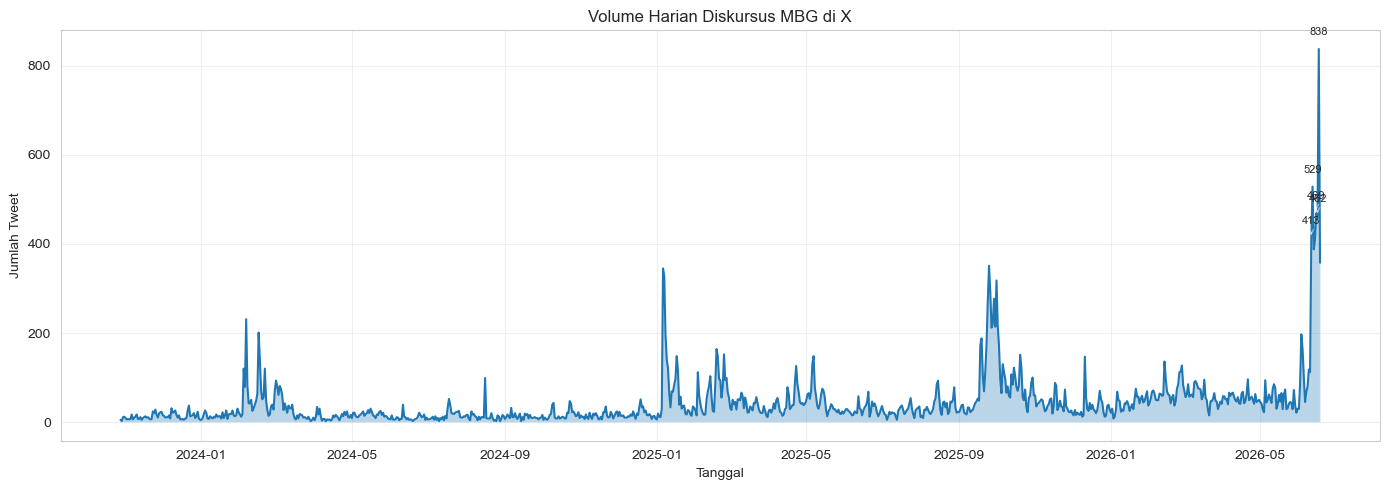

Top 5 tanggal dengan volume tweet tertinggi:


,tanggal,jumlah_tweet
0,2026-06-17,838
1,2026-06-12,529
2,2026-06-15,469
3,2026-06-16,462
4,2026-06-11,413


In [11]:
# Analisis Tren Waktu Tweet MBG
daily = (df_mbg.groupby('date_only').size())
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily.index, daily.values, linewidth=1.5)
ax.fill_between(daily.index, daily.values, alpha=0.3)

ax.set_xlabel('Tanggal')
ax.set_ylabel('Jumlah Tweet')
ax.set_title('Volume Harian Diskursus MBG di X')
ax.grid(alpha=0.3)

# Top 5 spike diskusi
top_spikes = daily.nlargest(5)
for date, count in top_spikes.items():
    ax.annotate(
        f'{count}',
        xy=(date, count),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=8,
        arrowprops=dict(
            arrowstyle='->',
            alpha=0.5
        )
    )
plt.tight_layout()
plt.show()

# Ringkasan Spike Tertinggi
spike_df = (top_spikes.reset_index())
spike_df.columns = ['tanggal','jumlah_tweet']
print("Top 5 tanggal dengan volume tweet tertinggi:")
display(spike_df)

In [12]:
target_date = pd.to_datetime('2026-06-17').date()
spike_df = df_mbg[df_mbg['date_only'] == target_date].copy()

print(f'ZOOM IN: {target_date}')
print(f'Total tweet: {len(spike_df):,}\n')

# Top 5 Tweet Paling Viral
print('Top 5 tweet dengan view tertinggi:')

top_spike = spike_df.nlargest(5, 'viewCount')[[
        'username',
        'viewCount',
        'replyCount',
        'retweetCount',
        'likeCount',
        'text'
    ]
]

for _, row in top_spike.iterrows():
    print(f"\n[@{row['username']}] "
        f"Views={row['viewCount']:,} "
        f"Likes={row['likeCount']:,} "
        f"Replies={row['replyCount']:,} "
        f"RT={row['retweetCount']:,}"
    )
    print(row['text'][:300])
    print('-' * 80)

# Top 10 User Paling Aktif
print('\nTop 10 user paling aktif pada tanggal tersebut:')
print(spike_df['username'].value_counts().head(10))

# Statistik Engagement Hari Tersebut
print('\nRingkasan Engagement')
print(f"Total views : {spike_df['viewCount'].sum():,}")
print(f"Total likes : {spike_df['likeCount'].sum():,}")
print(f"Total retweet : {spike_df['retweetCount'].sum():,}")
print(f"Total replies : {spike_df['replyCount'].sum():,}")

ZOOM IN: 2026-06-17
Total tweet: 838

Top 5 tweet dengan view tertinggi:

[@kompascom] Views=1,103,149 Likes=795 Replies=662 RT=148
Aliansi Masyarakat Jakarta Timur menggelar aksi demonstrasi di kawasan Patung Kuda, Medan Merdeka Selatan, Jakarta Pusat, Rabu (17/6/2026). Massa menyuarakan dua tuntutan utama yakni mendukung keberlanjutan program Makan Bergizi Gratis (MBG) dan mendesak pengusutan tuntas kasus korupsi.

~NJ
--------------------------------------------------------------------------------

[@kompascom] Views=502,815 Likes=5,256 Replies=112 RT=1,058
Ketua DPRD Kota Malang, Amithya Ratnanggani Sirraduhita, menyatakan penolakannya terhadap program Makan Bergizi Gratis.

~NJ https://t.co/zFpGJ7SiHn
--------------------------------------------------------------------------------

[@Jakartalk] Views=229,728 Likes=4,641 Replies=214 RT=618
Nyenggol AA clan dicuekin, sekarang coba mainin narasi dukung MBG, timingnya disaat banyak orang demo menuntut evaluasi bahkan stop MBG.

MBG ud

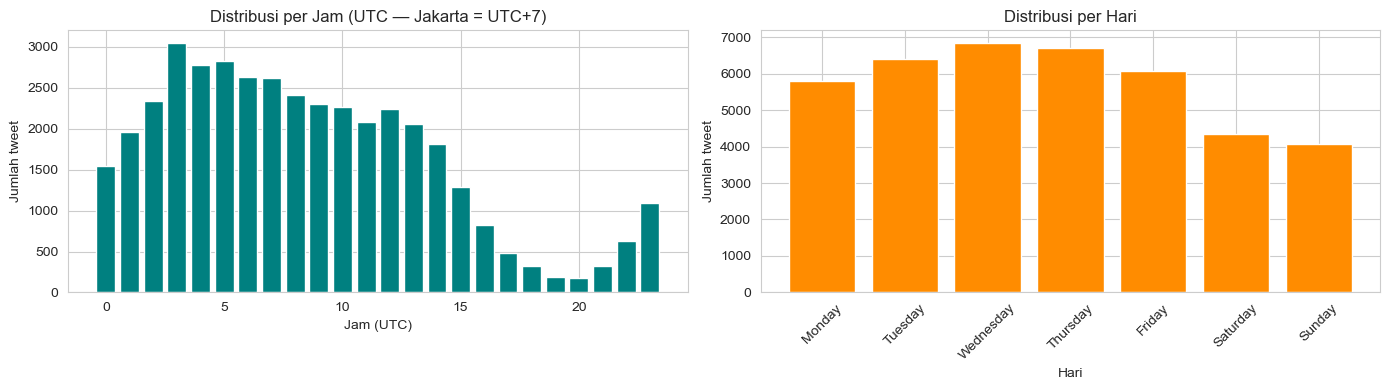

In [13]:
# Pola jam dan hari
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hourly = df_mbg.groupby('hour').size()
axes[0].bar(hourly.index, hourly.values, color='teal')
axes[0].set_xlabel('Jam (UTC)')
axes[0].set_ylabel('Jumlah tweet')
axes[0].set_title('Distribusi per Jam (UTC — Jakarta = UTC+7)')

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow = df_mbg['day_of_week'].value_counts().reindex(day_order)
axes[1].bar(dow.index, dow.values, color='darkorange')
axes[1].set_xlabel('Hari')
axes[1].set_ylabel('Jumlah tweet')
axes[1].set_title('Distribusi per Hari')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 4b. Zoom-In: Krisis 17 Juni 2026
Dari sampel tweet dengan jumlah tayangan tertinggi terlihat bahwa percakapan terkait MBG pada tanggal 17 Juni 2026 didominasi oleh pemberitaan media massa, unggahan institusi pemerintah, serta opini publik yang menyoroti isu demonstrasi dan dugaan korupsi dalam program MBG. Hal ini menunjukkan bahwa lonjakan percakapan pada periode tersebut dipengaruhi oleh peristiwa aktual  (*event-driven discussion*) dan pemberitaan media yang memicu tingginya perhatian publik terhadap isu MBG.

In [14]:
# Identifikasi event dari kata kunci di tweet
target_date = pd.to_datetime('2026-06-17').date()
spike_df = df_mbg[df_mbg['date_only'] == target_date].copy()

print(f'ANALISIS SPIKE: {target_date} ({len(spike_df)} tweet) \n')

# Kata kunci yang mungkin mengindikasi event
event_keywords = {
    'demonstrasi': ['demo', 'demonstrasi', 'aksi', 'massa', 'unjuk rasa', 'patung kuda'],
    'korupsi': ['korupsi', 'ladang korupsi', 'bancakan', 'audit', 'penyelewengan', 'mark up', 'gratifikasi', 'usut', 'pengusutan'],
    'kritik_program': ['tolak mbg', 'stop mbg', 'evaluasi mbg', 'gagal', 'bermasalah', 'kritik', 'penolakan', 'tidak setuju'],
    'dukungan_program': ['dukung mbg', 'lanjutkan mbg', 'keberlanjutan', 'mendukung', 'sukses', 'bermanfaat'],
    'kebijakan': ['evaluasi', 'investigasi', 'audit', 'kepala bgn', 'anggaran', 'kebijakan', 'program pemerintah', 'pengawasan'],
    'implementasi': ['distribusi', 'porsi makanan', 'sppg', 'dapur mbg', 'makan bergizi gratis','pelaksanaan', 'penyaluran']
}

spike_text = spike_df['text'].fillna('').str.lower()

print('Frekuensi kata kunci event:')
for category, keywords in event_keywords.items():
    pattern = '|'.join(keywords)
    count = spike_text.str.contains(pattern, regex=True).sum()
    pct = count / len(spike_df) * 100
    bar = '#' * int(pct / 2)
    print(f'  {category:<18} {count:>4} tweet ({pct:>5.1f}%) {bar}')

ANALISIS SPIKE: 2026-06-17 (838 tweet) 

Frekuensi kata kunci event:
  demonstrasi          87 tweet ( 10.4%) #####
  korupsi              78 tweet (  9.3%) ####
  kritik_program       65 tweet (  7.8%) ###
  dukungan_program     80 tweet (  9.5%) ####
  kebijakan           286 tweet ( 34.1%) #################
  implementasi        614 tweet ( 73.3%) ####################################


In [15]:
# Bagaimana pola interaksi saat terjadi lonjakan percakapan MBG?
print('STRUKTUR INTERAKSI PADA SPIKE\n')

spike_reply = spike_df['isReply'].fillna(False).astype(bool)
spike_quote = spike_df['isQuote'].fillna(False).astype(bool)
spike_standalone = ~(spike_reply | spike_quote)

print(f'Reply       : {spike_reply.sum():>4} ({spike_reply.mean()*100:.1f}%)')
print(f'Quote       : {spike_quote.sum():>4} ({spike_quote.mean()*100:.1f}%)')
print(f'Standalone  : {spike_standalone.sum():>4} ({spike_standalone.mean()*100:.1f}%)')

# Bandingkan dengan keseluruhan dataset
all_reply_pct = df_dedup['isReply'].fillna(False).astype(bool).mean() * 100

print(f'\nRata-rata seluruh dataset, reply = {all_reply_pct:.1f}%')
print(f'Selisih: {spike_reply.mean()*100 - all_reply_pct:+.1f} percentage point')

STRUKTUR INTERAKSI PADA SPIKE

Reply       :  264 (31.5%)
Quote       :   62 (7.4%)
Standalone  :  512 (61.1%)

Rata-rata seluruh dataset, reply = 33.9%
Selisih: -2.4 percentage point


Pada periode lonjakan percakapan tanggal 17 Juni 2026, mayoritas unggahan berupa tweet mandiri (standalone) dengan proporsi 61,1%, diikuti oleh reply sebesar 31,5% dan quote sebesar 7,4%. Dibandingkan dengan rata-rata keseluruhan dataset, proporsi reply pada periode tersebut sedikit lebih rendah sebesar 2,4 poin persentase.

Temuan ini menunjukkan bahwa lonjakan percakapan tidak didominasi oleh interaksi antar pengguna dalam bentuk diskusi atau perdebatan, melainkan lebih banyak dipicu oleh munculnya unggahan baru dari berbagai akun. Kondisi tersebut sejalan dengan hasil analisis tweet teratas yang menunjukkan dominasi pemberitaan media massa dan unggahan institusi terkait isu demonstrasi, kritik, serta dugaan korupsi pada program MBG.

In [16]:
# ngram analysis — apa yang beda dari hari biasa?
from collections import Counter
import re

def tokenize(text):
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    # buang kata terlalu pendek dan stopwords basic
    stopwords = {'yang', 'di', 'ke', 'dari', 'untuk', 'dengan', 'ini', 'itu',
                 'dan', 'atau', 'juga', 'saja', 'sudah', 'akan', 'tidak', 'ada',
                 'pada', 'oleh', 'dalam', 'tetapi', 'tapi', 'jadi', 'bisa',
                 'saya', 'kita', 'kami', 'kamu', 'mereka', 'dia', 'nya',
                 'ya', 'gak', 'nggak', 'aja', 'sih', 'dong', 'kok', 'kan',
                 'rt', 'amp', 'jg', 'gw', 'gue', 'lu', 'lo', 'kalo'}
    return [t for t in tokens if len(t) > 3 and t not in stopwords]

# Kata di spike
spike_tokens = []
for text in spike_df['text'].fillna(''):
    spike_tokens.extend(tokenize(text))

# Kata di seluruh dataset (untuk baseline)
sample_size = min(5000, len(df))
baseline_df = df.sample(sample_size, random_state=42)
baseline_tokens = []
for text in baseline_df['text'].fillna(''):
    baseline_tokens.extend(tokenize(text))

spike_freq = Counter(spike_tokens)
baseline_freq = Counter(baseline_tokens)

# Normalisasi (per 1000 token)
spike_total = sum(spike_freq.values())
baseline_total = sum(baseline_freq.values())

# Kata yang OVER-REPRESENTED di spike vs baseline
distinctive_words = []
for word, count in spike_freq.most_common(100):
    if count < 5:
        continue
    spike_rate = count / spike_total * 1000
    baseline_rate = baseline_freq.get(word, 0) / baseline_total * 1000
    if baseline_rate > 0:
        lift = spike_rate / baseline_rate
    else:
        lift = float('inf')
    distinctive_words.append((word, count, spike_rate, baseline_rate, lift))

distinctive_words.sort(key=lambda x: x[4], reverse=True)

print('Kata-kata yang LEBIH SERING di spike dibanding hari normal (top 20):')
print(f'{"Word":<20} {"Count":>6} {"Spike/1k":>10} {"Norm/1k":>10} {"Lift":>8}')
print('-' * 60)
for word, count, sr, br, lift in distinctive_words[:20]:
    lift_str = f'{lift:.1f}x' if lift != float('inf') else 'NEW'
    print(f'{word:<20} {count:>6} {sr:>10.2f} {br:>10.2f} {lift_str:>8}')

print('\nLift tinggi = kata yang sangat khas untuk spike ini. Ini petunjuk event.')

Kata-kata yang LEBIH SERING di spike dibanding hari normal (top 20):
Word                  Count   Spike/1k    Norm/1k     Lift
------------------------------------------------------------
penajam                 148       5.60       0.00      NEW
paser                   148       5.60       0.00      NEW
qodari                   64       2.42       0.01   449.6x
diperiksa                76       2.88       0.02   177.9x
polres                  242       9.16       0.15    60.7x
aksi                     80       3.03       0.08    40.1x
didistribusikan          87       3.29       0.09    35.9x
polri                   220       8.33       0.23    35.9x
makmur                   50       1.89       0.06    31.9x
wujudkan                 50       1.89       0.06    29.3x
utara                   149       5.64       0.23    24.3x
ketat                    91       3.44       0.16    22.0x
mahasiswa                98       3.71       0.22    17.2x
aman                    169       6.40      

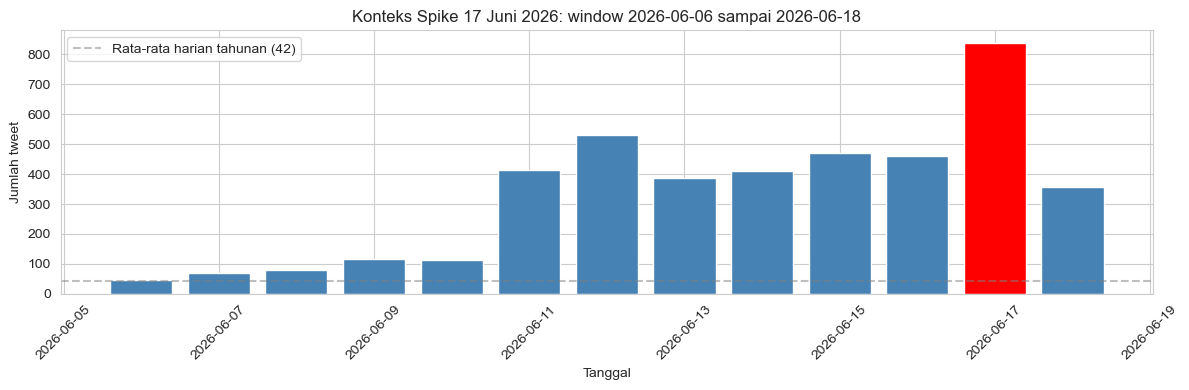


Rata-rata 10 hari SEBELUM spike: 281 tweet/hari
Spike day                      : 838 tweet
Rata-rata 10 hari SETELAH spike: 358 tweet/hari

Elevasi spike vs sebelum: +198%
Apakah ada "tail" (elevasi setelah spike): TIDAK


In [17]:
# Cek apakah spike 25 Sept adalah event satu hari atau ada tail
window_start = pd.to_datetime('2026-06-06').date()
window_end   = pd.to_datetime('2026-06-18').date()

window_df = df_mbg [(df_mbg['date_only'] >= window_start) & (df_mbg['date_only'] <= window_end)]
daily_window = window_df.groupby('date_only').size()

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['red' if d == target_date else 'steelblue' for d in daily_window.index]
ax.bar(daily_window.index, daily_window.values, color=colors)
ax.axhline(y=daily.mean(), color='gray', linestyle='--', alpha=0.5,
           label=f'Rata-rata harian tahunan ({daily.mean():.0f})')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Jumlah tweet')
ax.set_title(f'Konteks Spike 17 Juni 2026: window {window_start} sampai {window_end}')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Hitung tail
pre_spike = daily_window[daily_window.index < target_date].mean()
post_spike = daily_window[daily_window.index > target_date].mean()
spike_value = daily_window[target_date]

print(f'\nRata-rata 10 hari SEBELUM spike: {pre_spike:.0f} tweet/hari')
print(f'Spike day                      : {spike_value} tweet')
print(f'Rata-rata 10 hari SETELAH spike: {post_spike:.0f} tweet/hari')
print(f'\nElevasi spike vs sebelum: {(spike_value/pre_spike - 1)*100:+.0f}%')
print(f'Apakah ada "tail" (elevasi setelah spike): {"YA" if post_spike > pre_spike * 1.3 else "TIDAK"}')

In [18]:
# Cek kata kunci keracunan di 3 spike September
sept_dates = [pd.to_datetime(d).date() for d in ['2026-06-12', '2026-06-15', '2026-06-17']]

for d in sept_dates:
    sub = df_mbg[df_mbg['date_only'] == d]
    text = sub['text'].fillna('').str.lower()
    racun = text.str.contains('evaluasi|aksi|korupsi|dihentikan|tepat|sasaran|korupsi', regex=True).sum()
    print(f'{d}: {len(sub)} tweet, {racun} mention keracunan ({racun/len(sub)*100:.1f}%)')

2026-06-12: 529 tweet, 178 mention keracunan (33.6%)
2026-06-15: 469 tweet, 192 mention keracunan (40.9%)
2026-06-17: 838 tweet, 413 mention keracunan (49.3%)


In [19]:
# Trend bulanan: mention keracunan per bulan
df_mbg['month'] = df_mbg['datetime'].dt.to_period('M')
text_lower = df_mbg['text'].fillna('').str.lower()
df_mbg['mentions_dihentikan'] = text_lower.str.contains(
        r'evaluasi|aksi|korupsi|audit|'
        r'dihentikan|stop mbg|tolak mbg|'
        r'pengawasan|tepat sasaran|protes', regex=True)

monthly = df_mbg.groupby('month').agg(
    total_tweet=('id', 'count'),
    dihentikan_count=('mentions_dihentikan', 'sum')
).reset_index()
monthly['dihentikan_pct'] = monthly['dihentikan_count'] / monthly['total_tweet'] * 100
monthly['month_str'] = monthly['month'].astype(str)

print('Trend dihentikan per bulan:')
print(monthly[['month_str', 'total_tweet', 'dihentikan_count', 'dihentikan_pct']].to_string(index=False))

Trend dihentikan per bulan:
month_str  total_tweet  dihentikan_count  dihentikan_pct
  2023-10           30                 1        3.333333
  2023-11          365                14        3.835616
  2023-12          450                21        4.666667
  2024-01          462                14        3.030303
  2024-02         1818               105        5.775578
  2024-03          882                35        3.968254
  2024-04          364                20        5.494505
  2024-05          523                24        4.588910
  2024-06          296                13        4.391892
  2024-07          456                18        3.947368
  2024-08          418                18        4.306220
  2024-09          358                 6        1.675978
  2024-10          517                21        4.061896
  2024-11          440                24        5.454545
  2024-12          553                28        5.063291
  2025-01         2272               222        9.771127
  2

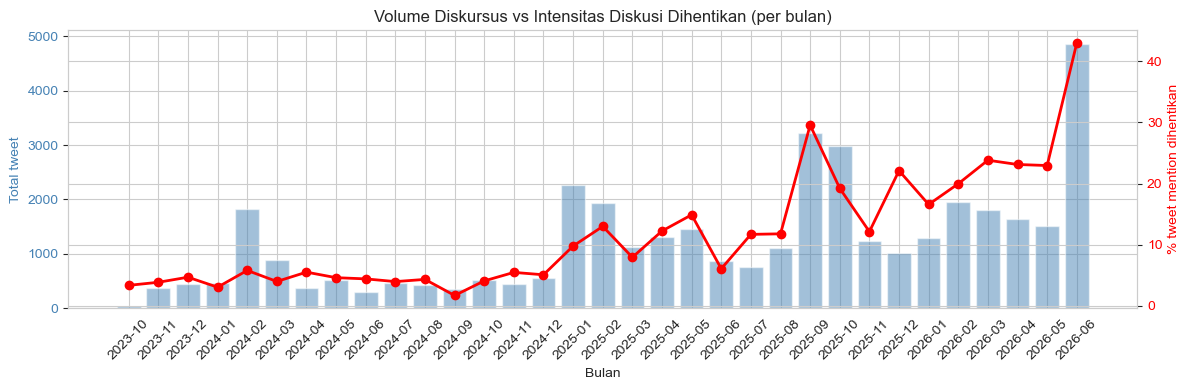

In [20]:
# Visualisasi
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(monthly['month_str'], monthly['total_tweet'], color='steelblue', alpha=0.5, label='Total tweet')
ax1.set_xlabel('Bulan')
ax1.set_ylabel('Total tweet', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
plt.xticks(rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly['month_str'], monthly['dihentikan_pct'], color='red', marker='o', linewidth=2, label='% mention dihentikan')
ax2.set_ylabel('% tweet mention dihentikan', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Volume Diskursus vs Intensitas Diskusi Dihentikan (per bulan)')
plt.tight_layout()
plt.show()

In [21]:
# Zoom September 2025: cari tanggal dengan diskusi evaluasi/kritik MBG tertinggi

june_df = df_mbg[(df_mbg['datetime'].dt.year == 2026) & (df_mbg['datetime'].dt.month == 6)].copy()

june_df['issue_flag'] = (june_df['text'].fillna('').str.lower().str.contains(
        r'evaluasi|aksi|korupsi|audit|'
        r'dihentikan|stop mbg|tolak mbg|'
        r'pengawasan|tepat sasaran|protes',
        regex=True))

june_daily = (june_df.groupby('date_only').agg(total=('id', 'count'), issue=('issue_flag', 'sum'))
    .reset_index())

june_daily['pct'] = (june_daily['issue'] / june_daily['total'] * 100)

print('Top 5 hari dengan diskusi evaluasi/kritik MBG tertinggi:')
print(june_daily.nlargest(5, 'issue')[['date_only', 'total', 'issue', 'pct']].to_string(index=False))

Top 5 hari dengan diskusi evaluasi/kritik MBG tertinggi:
 date_only  total  issue       pct
2026-06-17    838    422 50.357995
2026-06-16    462    211 45.670996
2026-06-15    469    198 42.217484
2026-06-12    529    184 34.782609
2026-06-11    413    161 38.983051


In [22]:
# Sample tweet top engagement pada hari dengan isu MBG tertinggi
top_june_date = june_daily.nlargest(1, 'issue')['date_only'].iloc[0]
top_june_tweets = (june_df[(june_df['date_only'] == top_june_date) &(june_df['issue_flag'])]
    .nlargest(5, 'viewCount')[['username', 'text', 'viewCount']])

print(f'\nTop 5 tweet isu MBG pada {top_june_date}:')

for _, row in top_june_tweets.iterrows():
    print(f"\n[@{row['username']}] Views={row['viewCount']:,}")
    print(row['text'][:280])
    print('-' * 80)


Top 5 tweet isu MBG pada 2026-06-17:

[@kompascom] Views=1,103,149
Aliansi Masyarakat Jakarta Timur menggelar aksi demonstrasi di kawasan Patung Kuda, Medan Merdeka Selatan, Jakarta Pusat, Rabu (17/6/2026). Massa menyuarakan dua tuntutan utama yakni mendukung keberlanjutan program Makan Bergizi Gratis (MBG) dan mendesak pengusutan tuntas kasus k
--------------------------------------------------------------------------------

[@Jakartalk] Views=229,728
Nyenggol AA clan dicuekin, sekarang coba mainin narasi dukung MBG, timingnya disaat banyak orang demo menuntut evaluasi bahkan stop MBG.

MBG udah terbukti ladang koruptor loh, Mo? Miliaran perhari.

Oh iya, hampir lupa.

Izin 🙏🏻
--------------------------------------------------------------------------------

[@humaspolrestas2] Views=132,017
Polri melalui Polres Penajam Paser Utara terus memastikan Program Makan Bergizi Gratis (MBG) berjalan aman, sehat, dan tepat sasaran bagi masyarakat. Sebelum didistribusikan, sebanyak 1.340 porsi m

In [23]:
# Tanggal terakhir per bulan
last_dates = df_mbg.groupby(df_mbg['datetime'].dt.to_period('M'))['datetime'].max()
first_dates = df_mbg.groupby(df_mbg['datetime'].dt.to_period('M'))['datetime'].min()

print('Tanggal cakupan per bulan:')
for month in last_dates.index:
    print(f'  {month}: {first_dates[month].date()} sampai {last_dates[month].date()}')

Tanggal cakupan per bulan:
  2023-10: 2023-10-28 sampai 2023-10-31
  2023-11: 2023-11-01 sampai 2023-11-30
  2023-12: 2023-12-01 sampai 2023-12-31
  2024-01: 2024-01-01 sampai 2024-01-31
  2024-02: 2024-02-01 sampai 2024-02-29
  2024-03: 2024-03-01 sampai 2024-03-31
  2024-04: 2024-04-01 sampai 2024-04-30
  2024-05: 2024-05-01 sampai 2024-05-31
  2024-06: 2024-06-01 sampai 2024-06-30
  2024-07: 2024-07-01 sampai 2024-07-31
  2024-08: 2024-08-01 sampai 2024-08-31
  2024-09: 2024-09-01 sampai 2024-09-30
  2024-10: 2024-10-01 sampai 2024-10-31
  2024-11: 2024-11-01 sampai 2024-11-30
  2024-12: 2024-12-01 sampai 2024-12-31
  2025-01: 2025-01-01 sampai 2025-01-31
  2025-02: 2025-02-01 sampai 2025-02-28
  2025-03: 2025-03-01 sampai 2025-03-31
  2025-04: 2025-04-01 sampai 2025-04-30
  2025-05: 2025-05-01 sampai 2025-05-31
  2025-06: 2025-06-01 sampai 2025-06-30
  2025-07: 2025-07-01 sampai 2025-07-31
  2025-08: 2025-08-01 sampai 2025-08-31
  2025-09: 2025-09-01 sampai 2025-09-30
  2025-10: 20

# 5. Validasi Feasibility SNA Kritis
Ini section paling penting untuk menentukan apakah Social Network Analysis layak dilakukan.

Kriteria: jika >40% tweet punya interaksi (reply/quote), SNA solid. Kalau <20%, harus pivot ke hashtag co-occurrence atau semantic network.

In [24]:
#Definisi Interaksi
has_reply = df_mbg['isReply'].fillna(False).astype(bool)
has_quote = df_mbg['isQuote'].fillna(False).astype(bool)
has_any_interaction = has_reply | has_quote

interaction_stats = pd.DataFrame({
    'Jenis Interaksi': [
        'Reply',
        'Quote',
        'Setidaknya Satu Interaksi',
        'Standalone'
    ],
    'Jumlah': [
        has_reply.sum(),
        has_quote.sum(),
        has_any_interaction.sum(),
        (~has_any_interaction).sum()
    ],
    'Persentase': [
        f'{has_reply.mean()*100:.1f}%',
        f'{has_quote.mean()*100:.1f}%',
        f'{has_any_interaction.mean()*100:.1f}%',
        f'{(~has_any_interaction).mean()*100:.1f}%'
    ]
})

print(interaction_stats.to_string(index=False))

          Jenis Interaksi  Jumlah Persentase
                    Reply   13519      33.6%
                    Quote    3664       9.1%
Setidaknya Satu Interaksi   17048      42.3%
               Standalone   23208      57.7%


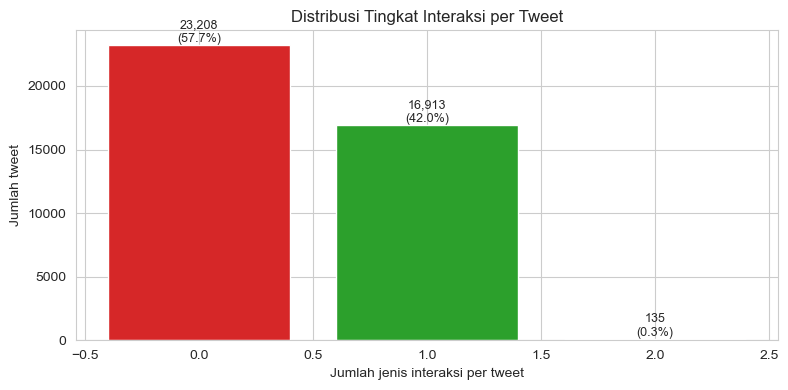

In [25]:
# Jumlah jenis interaksi per tweet
interaction_count = (has_reply.astype(int) +has_quote.astype(int))
ic_dist = interaction_count.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d62728', '#2ca02c', '#1f77b4']
ax.bar(ic_dist.index,ic_dist.values,color=colors[:len(ic_dist)])

ax.set_xlabel('Jumlah jenis interaksi per tweet')
ax.set_ylabel('Jumlah tweet')
ax.set_title('Distribusi Tingkat Interaksi per Tweet')

for i, v in enumerate(ic_dist.values): ax.text(ic_dist.index[i], v, f'{v:,}\n({v/len(df_mbg)*100:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

Berdasarkan distribusi tingkat interaksi, sebanyak 23.208 tweet (57,7%) merupakan tweet mandiri (*standalone*) yang tidak memiliki hubungan langsung dengan tweet lain. Sementara itu, 16.913 tweet (42,0%) memiliki setidaknya satu bentuk interaksi berupa *reply* atau *quote tweet*, dan hanya 135 tweet (0,3%) yang memiliki lebih dari satu jenis interaksi secara bersamaan.

Hasil ini menunjukkan bahwa meskipun mayoritas percakapan terkait MBG masih didominasi oleh unggahan mandiri, terdapat proporsi interaksi yang cukup besar antar pengguna. Dengan lebih dari 40% tweet terhubung melalui mekanisme *reply* atau *quote*, dataset dinilai memiliki struktur jaringan yang memadai untuk dilakukan Social Network Analysis (SNA). Interaksi tersebut memungkinkan identifikasi akun sentral, pola penyebaran informasi, serta hubungan percakapan yang terbentuk dalam diskusi mengenai program MBG.

#  6. Duplicate / Near-Duplicate Detection

Tweet identik atau hampir identik dari banyak akun = sinyal koordinasi kuat.


In [26]:
def normalize_text(text):
    if not isinstance(text, str):
        return ''

    text = text.lower()
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df_mbg['text_normalized'] = df_mbg['text'].apply(normalize_text)
df_mbg['text_normalized'] = (df_mbg['text_normalized'].replace('', np.nan))
df_mbg['normalized_word_count'] = (df_mbg['text_normalized'].fillna('').str.split().str.len())
meaningful_mask = (df_mbg['normalized_word_count'] >= 10)
meaningful_dup = (df_mbg.loc[meaningful_mask,'text_normalized'].value_counts())
meaningful_dup = meaningful_dup[meaningful_dup > 1]

print(f'Tweet bermakna (>=10 kata): {meaningful_mask.sum():,}')
print(f'Teks bermakna unik yang muncul >1x: {len(meaningful_dup):,}')
print(f'Total duplicate bermakna: 'f'{meaningful_dup.sum():,} 'f'({meaningful_dup.sum()/len(df_mbg)*100:.2f}%)')
print('\nTop 10 duplicate bermakna:')
for text, count in meaningful_dup.head(10).items():
    n_users = (df_mbg[df_mbg['text_normalized'] == text]['username'].nunique())
    flag = '[FLAG]' if n_users >= 5 else ''
    print(f'\n{flag} [{count}x dari {n_users} user unik]')
    print(f'   {text[:250]}')

Tweet bermakna (>=10 kata): 38,694
Teks bermakna unik yang muncul >1x: 900
Total duplicate bermakna: 2,510 (6.24%)

Top 10 duplicate bermakna:

[FLAG] [41x dari 41 user unik]
   polri melalui polres penajam paser utara terus memastikan program makan bergizi gratis (mbg) berjalan aman, sehat, dan tepat sasaran bagi masyarakat. sebelum didistribusikan, sebanyak 1.340 porsi makanan diperiksa secara ketat oleh tim pengawasan pol

[FLAG] [38x dari 37 user unik]
   polri melalui polres penajam paser utara terus memastikan program makan bergizi gratis (mbg) berjalan aman, sehat, dan tepat sasaran bagi masyarakat.

 [35x dari 1 user unik]
   🆘 darurat gaza – saatnya bertindak! [alhamdulilkah bisa scan qris] 💔 gaza kembali dilanda kehancuran. 💔 rumah, sekolah, dan masjid hancur jadi puing. 💔 anak-anak menangis tanpa orang tua. 💔 luka, kelaparan, dan haus kini jadi keseharian mereka. merek

 [29x dari 1 user unik]
   🆘 darurat gaza! ayo bantu! pulihkan kemanusiaan! aksi peduli untuk palestina ❤️

Analisis duplikasi teks menunjukkan bahwa dari 38.694 tweet bermakna, terdapat 2.510 tweet (6,24%) yang memiliki isi identik dengan tweet lain. Persentase tersebut relatif rendah sehingga menunjukkan bahwa percakapan mengenai MBG secara umum masih didominasi oleh konten yang beragam.

Meskipun demikian, ditemukan sejumlah teks yang dipublikasikan secara identik oleh banyak akun berbeda. Beberapa di antaranya merupakan narasi mengenai dukungan institusi terhadap program MBG, khususnya yang berasal dari lingkungan kepolisian dan instansi pemerintah. Temuan ini mengindikasikan adanya pola penyebaran informasi yang terkoordinasi atau bersumber dari materi publikasi yang sama, seperti siaran pers dan kampanye komunikasi publik.

Namun demikian, temuan ini tidak cukup untuk menyimpulkan adanya aktivitas manipulatif atau operasi bot. Diperlukan analisis tambahan seperti kesamaan waktu unggahan, pola jaringan interaksi, dan karakteristik akun untuk memverifikasi adanya perilaku terkoordinasi secara lebih meyakinkan.

# 7. Sanity Check Bahasa & Karakteristik Teks

Distribusi kolom lang:
lang
in    40148
en       83
ja       15
ht        4
tr        1
fr        1
pl        1
zh        1
fi        1
cs        1
Name: count, dtype: int64


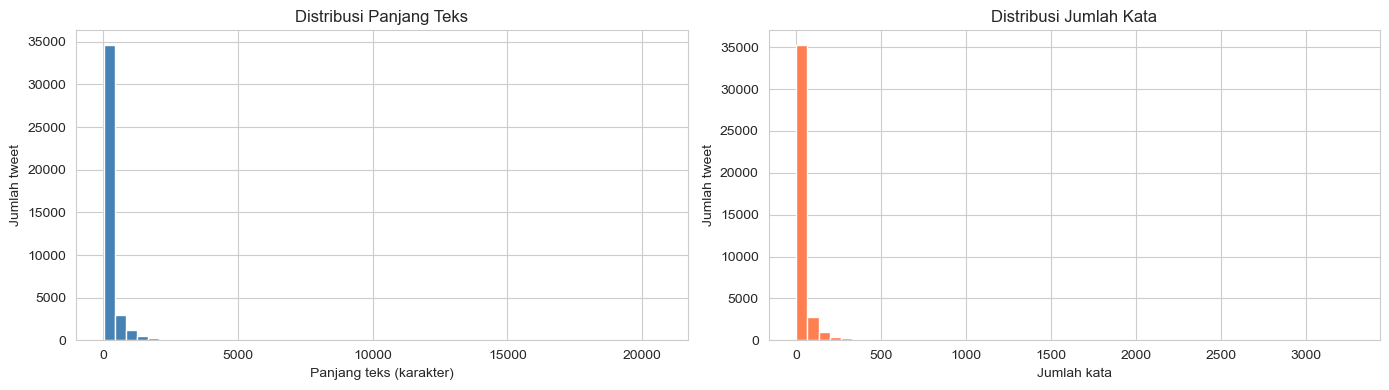


Panjang teks rata-rata: 352 karakter
Median jumlah kata: 34
Tweet sangat pendek (<5 kata): 70


In [27]:
print('Distribusi kolom lang:')
print(df_mbg['lang'].value_counts().head(10))

df_mbg['text_length'] = df_mbg['text'].fillna('').str.len()
df_mbg['word_count'] = df_mbg['text'].fillna('').str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df_mbg['text_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Panjang teks (karakter)')
axes[0].set_ylabel('Jumlah tweet')
axes[0].set_title('Distribusi Panjang Teks')

axes[1].hist(df_mbg['word_count'], bins=50, color='coral', edgecolor='white')
axes[1].set_xlabel('Jumlah kata')
axes[1].set_ylabel('Jumlah tweet')
axes[1].set_title('Distribusi Jumlah Kata')
plt.tight_layout()
plt.show()

print(f'\nPanjang teks rata-rata: {df_mbg["text_length"].mean():.0f} karakter')
print(f'Median jumlah kata: {df_mbg["word_count"].median():.0f}')
print(f'Tweet sangat pendek (<5 kata): {(df_mbg["word_count"] < 5).sum():,}')

# 8. Ringkasan Temuan & Rekomendasi Pipeline

In [28]:
# Persentase konsentrasi user
top_1pct_pct = (top_1pct_tweets / n_tweets) * 100

# Persentase interaksi
reply_pct = has_reply.mean() * 100
quote_pct = has_quote.mean() * 100
interaction_pct = has_any_interaction.mean() * 100
standalone_pct = (~has_any_interaction).mean() * 100

# Persentase duplicate
duplicate_pct = (meaningful_dup.sum() / len(df_mbg)) * 100

print('=' * 60)
print('RINGKASAN EDA LAYER 1 — DATASET MBG')
print('=' * 60)

print('\nSKALA DATA')
print(f'   - Total tweet: {len(df_mbg):,}')
print(f'   - Total user unik: {n_users:,}')
print(f'   - Rentang waktu: {df_mbg["datetime"].min().date()} → {df_mbg["datetime"].max().date()}')
print(f'   - Durasi: {(df_mbg["datetime"].max() - df_mbg["datetime"].min()).days} hari')

print('\nKONSENTRASI USER')
print(f'   - Top 1% user menghasilkan {top_1pct_pct:.1f}% tweet')
print(f'   - User dengan >100 tweet: {(tweets_per_user > 100).sum()}')

print('\nFEASIBILITY SNA')
print(f'   - Tweet dengan interaksi: {interaction_pct:.1f}%')
print(f'   - Reply: {reply_pct:.1f}%')
print(f'   - Quote: {quote_pct:.1f}%')
print(f'   - Standalone: {standalone_pct:.1f}%')

print('\nDUPLIKASI KONTEN')
print(f'   - Duplicate text bermakna: {meaningful_dup.sum():,} tweet ({duplicate_pct:.1f}%)')
print(f'   - Teks unik yang muncul berulang: {len(meaningful_dup):,}')

print('\nKARAKTERISTIK TEKS')
print(f'   - Bahasa dominan: {df_mbg["lang"].value_counts().index[0]} ({df_mbg["lang"].value_counts(normalize=True).iloc[0]*100:.1f}%)')
print(f'   - Panjang rata-rata: {df_mbg["text_length"].mean():.0f} karakter')

RINGKASAN EDA LAYER 1 — DATASET MBG

SKALA DATA
   - Total tweet: 40,256
   - Total user unik: 12
   - Rentang waktu: 2023-10-28 → 2026-06-18
   - Durasi: 964 hari

KONSENTRASI USER
   - Top 1% user menghasilkan 32.7% tweet
   - User dengan >100 tweet: 29

FEASIBILITY SNA
   - Tweet dengan interaksi: 42.3%
   - Reply: 33.6%
   - Quote: 9.1%
   - Standalone: 57.7%

DUPLIKASI KONTEN
   - Duplicate text bermakna: 2,510 tweet (6.2%)
   - Teks unik yang muncul berulang: 900

KARAKTERISTIK TEKS
   - Bahasa dominan: in (99.7%)
   - Panjang rata-rata: 352 karakter
